<a href="https://colab.research.google.com/github/williamvianaborges/utm_pricing_model/blob/main/analise_sensibilidade_br_utm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Análise de Sensibilidade do Modelo Tarifário BR-UTM

Este notebook implementa uma análise de sensibilidade para o modelo tarifário sintético:

\[
P = \alpha + \beta_1 T + \beta_2 A + \beta_3 H + \beta_4^j V_j
\]

em que:

- \(P\): tarifa estimada;
- \(T\): tempo de reserva;
- \(A\): área reservada;
- \(H\): variável indicadora de horário de pico;
- \(V_j\): categoria procedimental da operação;
- \(\alpha, \beta_1, \beta_2, \beta_3, \beta_4^j\): parâmetros tarifários.

A análise está organizada em:

1. sensibilidade às variáveis operacionais;
2. sensibilidade aos parâmetros tarifários;
3. sensibilidade à margem de remuneração;
4. análise multivariada de cenários;
5. simulação de Monte Carlo;
6. elasticidades aproximadas.


In [ ]:

# ============================================================
# 1. Importação das bibliotecas
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração geral dos gráficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Semente para reprodutibilidade
np.random.seed(123)


## 2. Definição da função de precificação

In [ ]:

# ============================================================
# 2. Função do modelo tarifário
# ============================================================

def calcular_tarifa(T, A, H, categoria, parametros):
    """
    Calcula a tarifa estimada com base no modelo tarifário proposto.

    Modelo:
        P = alpha + beta_T*T + beta_A*A + beta_H*H + beta_categoria
    """

    alpha = parametros["alpha"]
    beta_T = parametros["beta_T"]
    beta_A = parametros["beta_A"]
    beta_H = parametros["beta_H"]
    beta_categoria = parametros["beta_categoria"][categoria]

    tarifa = alpha + beta_T*T + beta_A*A + beta_H*H + beta_categoria

    return tarifa



## 3. Definição dos parâmetros-base

Os valores abaixo são hipotéticos e servem para ilustrar a aplicação do modelo. Eles podem ser alterados posteriormente conforme dados reais de custos, demanda ou calibração regulatória.


In [ ]:

# ============================================================
# 3. Parâmetros iniciais do modelo
# ============================================================

parametros_base = {
    "alpha": 10,
    "beta_T": 0.2,
    "beta_A": 0.05,
    "beta_H": 15,
    "beta_categoria": {
        "V0_Automatica": 0,
        "V1_Baixa_complexidade": 5,
        "V2_Media_complexidade": 10,
        "V3_AIS": 20,
        "V4_NOTAM": 30,
        "V5_Termo_coordenacao": 40
    }
}

parametros_base


{'alpha': 10,
 'beta_T': 0.2,
 'beta_A': 0.05,
 'beta_H': 15,
 'beta_categoria': {'V0_Automatica': 0,
  'V1_Baixa_complexidade': 5,
  'V2_Media_complexidade': 10,
  'V3_AIS': 20,
  'V4_NOTAM': 30,
  'V5_Termo_coordenacao': 40}}


## 4. Definição da operação-base

A operação-base será usada como referência para as análises univariadas. Em cada análise, apenas uma variável é modificada, mantendo as demais constantes.


In [ ]:

# ============================================================
# 4. Operação-base
# ============================================================

operacao_base = {
    "T": 30,
    "A": 200,
    "H": 0,
    "categoria": "V0_Automatica"
}

tarifa_base = calcular_tarifa(
    T=operacao_base["T"],
    A=operacao_base["A"],
    H=operacao_base["H"],
    categoria=operacao_base["categoria"],
    parametros=parametros_base
)

print(f"Tarifa da operação-base: {tarifa_base:.2f}")


Tarifa da operação-base: 26.00


# 5. Sensibilidade às variáveis operacionais

## 5.1 Sensibilidade ao tempo de reserva \(T\)

In [ ]:

# ============================================================
# 5.1 Sensibilidade ao tempo de reserva T
# ============================================================

valores_T = np.arange(30, 130, 10)

resultados_T = []

for T in valores_T:
    tarifa = calcular_tarifa(
        T=T,
        A=operacao_base["A"],
        H=operacao_base["H"],
        categoria=operacao_base["categoria"],
        parametros=parametros_base
    )

    resultados_T.append({
        "T": T,
        "tarifa": tarifa
    })

df_sensibilidade_T = pd.DataFrame(resultados_T)

df_sensibilidade_T.head()


,T,tarifa
0,30,26.0
1,40,28.0
2,50,30.0
3,60,32.0
4,70,34.0


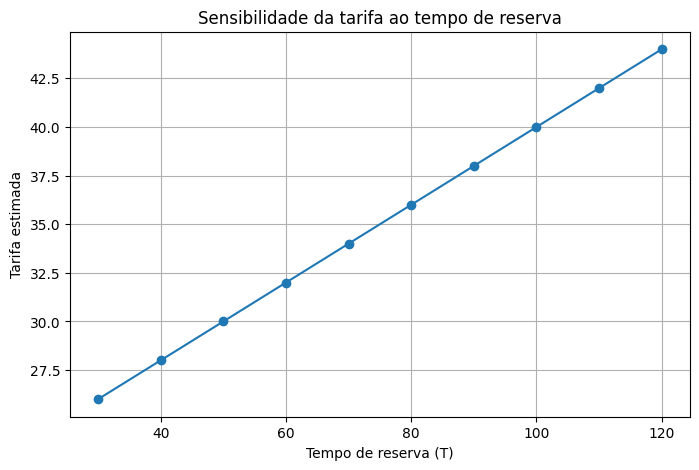

In [ ]:

plt.figure()
plt.plot(df_sensibilidade_T["T"], df_sensibilidade_T["tarifa"], marker="o")
plt.xlabel("Tempo de reserva (T)")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa ao tempo de reserva")
plt.show()


## 5.2 Sensibilidade à área reservada \(A\)

In [ ]:

# ============================================================
# 5.2 Sensibilidade à área reservada A
# ============================================================

valores_A = np.arange(200, 300, 10)

resultados_A = []

for A in valores_A:
    tarifa = calcular_tarifa(
        T=operacao_base["T"],
        A=A,
        H=operacao_base["H"],
        categoria=operacao_base["categoria"],
        parametros=parametros_base
    )

    resultados_A.append({
        "A": A,
        "tarifa": tarifa
    })

df_sensibilidade_A = pd.DataFrame(resultados_A)

df_sensibilidade_A.head()


,A,tarifa
0,200,26.0
1,210,26.5
2,220,27.0
3,230,27.5
4,240,28.0


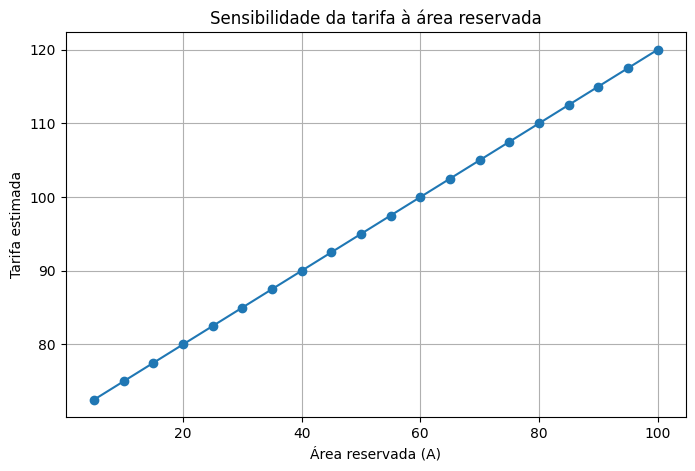

In [ ]:

plt.figure()
plt.plot(df_sensibilidade_A["A"], df_sensibilidade_A["tarifa"], marker="o")
plt.xlabel("Área reservada (A)")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa à área reservada")
plt.show()


## 5.3 Sensibilidade ao horário de pico \(H\)

In [ ]:

# ============================================================
# 5.3 Sensibilidade ao horário de pico H
# ============================================================

resultados_H = []

for H in [0, 1]:
    tarifa = calcular_tarifa(
        T=operacao_base["T"],
        A=operacao_base["A"],
        H=H,
        categoria=operacao_base["categoria"],
        parametros=parametros_base
    )

    resultados_H.append({
        "H": H,
        "descricao": "Horário normal" if H == 0 else "Horário de pico",
        "tarifa": tarifa
    })

df_sensibilidade_H = pd.DataFrame(resultados_H)

df_sensibilidade_H


,H,descricao,tarifa
0,0,Horário normal,26.0
1,1,Horário de pico,41.0


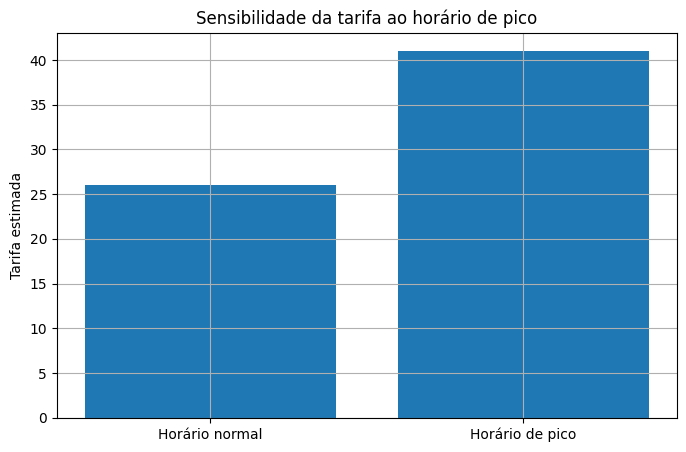

In [ ]:

plt.figure()
plt.bar(df_sensibilidade_H["descricao"], df_sensibilidade_H["tarifa"])
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa ao horário de pico")
plt.show()


## 5.4 Sensibilidade às categorias procedimentais \(V_j\)

In [ ]:

# ============================================================
# 5.4 Sensibilidade às categorias procedimentais
# ============================================================

categorias = list(parametros_base["beta_categoria"].keys())

resultados_categoria = []

for categoria in categorias:
    tarifa = calcular_tarifa(
        T=operacao_base["T"],
        A=operacao_base["A"],
        H=operacao_base["H"],
        categoria=categoria,
        parametros=parametros_base
    )

    resultados_categoria.append({
        "categoria": categoria,
        "tarifa": tarifa
    })

df_sensibilidade_categoria = pd.DataFrame(resultados_categoria)

df_sensibilidade_categoria


,categoria,tarifa
0,V0_Automatica,26.0
1,V1_Baixa_complexidade,31.0
2,V2_Media_complexidade,36.0
3,V3_AIS,46.0
4,V4_NOTAM,56.0
5,V5_Termo_coordenacao,66.0


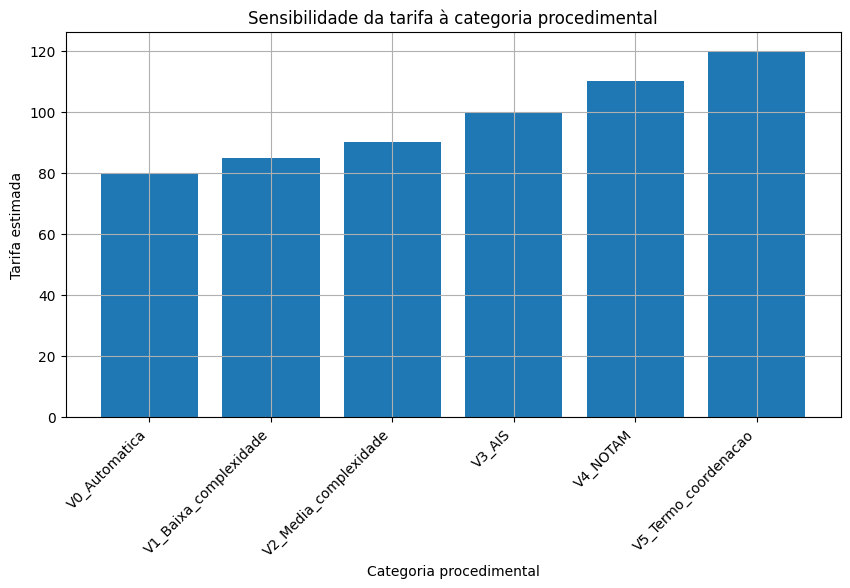

In [ ]:

plt.figure(figsize=(10, 5))
plt.bar(df_sensibilidade_categoria["categoria"], df_sensibilidade_categoria["tarifa"])
plt.xlabel("Categoria procedimental")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa à categoria procedimental")
plt.xticks(rotation=45, ha="right")
plt.show()



# 6. Sensibilidade aos parâmetros tarifários

Nesta etapa, os coeficientes do modelo são alterados. Essa análise é importante porque os parâmetros utilizados são hipotéticos e podem ser recalibrados futuramente.


In [ ]:

# ============================================================
# 6.1 Função para análise de sensibilidade de parâmetros
# ============================================================

def sensibilidade_parametro(nome_parametro, valores_parametro, operacao_base, parametros_base):
    """
    Realiza análise de sensibilidade para um parâmetro específico.

    nome_parametro pode ser:
        'alpha', 'beta_T', 'beta_A' ou 'beta_H'
    """

    resultados = []

    for valor in valores_parametro:
        parametros_temp = parametros_base.copy()
        parametros_temp["beta_categoria"] = parametros_base["beta_categoria"].copy()

        parametros_temp[nome_parametro] = valor

        tarifa = calcular_tarifa(
            T=operacao_base["T"],
            A=operacao_base["A"],
            H=operacao_base["H"],
            categoria=operacao_base["categoria"],
            parametros=parametros_temp
        )

        resultados.append({
            "parametro": nome_parametro,
            "valor_parametro": valor,
            "tarifa": tarifa
        })

    return pd.DataFrame(resultados)


In [ ]:
# Sensibilidade ao intercepto alpha
valores_alpha = np.arange(0, 31, 5)

df_sensibilidade_alpha = sensibilidade_parametro(
    nome_parametro="alpha",
    valores_parametro=valores_alpha,
    operacao_base=operacao_base,
    parametros_base=parametros_base
)

df_sensibilidade_alpha

,parametro,valor_parametro,tarifa
0,alpha,0,16.0
1,alpha,5,21.0
2,alpha,10,26.0
3,alpha,15,31.0
4,alpha,20,36.0
5,alpha,25,41.0
6,alpha,30,46.0


In [ ]:
# Sensibilidade aos coeficientes das categorias procedimentais beta_V
valores_beta_categoria = np.arange(0, 51, 10)

resultados_beta_categoria = []

for categoria in ["V1_Baixa_complexidade",
                  "V2_Media_complexidade",
                  "V3_AIS",
                  "V4_NOTAM",
                  "V5_Termo_coordenacao"]:

    for valor in valores_beta_categoria:
        parametros_temp = parametros_base.copy()
        parametros_temp["beta_categoria"][categoria] = valor

        tarifa = calcular_tarifa(
            T=operacao_base["T"],
            A=operacao_base["A"],
            H=operacao_base["H"],
            categoria=categoria,
            parametros=parametros_temp
        )

        resultados_beta_categoria.append({
            "parametro": f"beta_{categoria}",
            "categoria": categoria,
            "valor_parametro": valor,
            "tarifa": tarifa
        })

df_sensibilidade_beta_categoria = pd.DataFrame(resultados_beta_categoria)

df_sensibilidade_beta_categoria

,parametro,categoria,valor_parametro,tarifa
0,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,0,26.0
1,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,10,36.0
2,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,20,46.0
3,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,30,56.0
4,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,40,66.0
5,beta_V1_Baixa_complexidade,V1_Baixa_complexidade,50,76.0
6,beta_V2_Media_complexidade,V2_Media_complexidade,0,26.0
7,beta_V2_Media_complexidade,V2_Media_complexidade,10,36.0
8,beta_V2_Media_complexidade,V2_Media_complexidade,20,46.0
9,beta_V2_Media_complexidade,V2_Media_complexidade,30,56.0


## 6.2 Sensibilidade ao parâmetro \(\beta_1\), associado ao tempo

In [ ]:

# ============================================================
# 6.2 Sensibilidade ao beta_T
# ============================================================

valores_beta_T = np.arange(0.05, 0.15, 0.01)

df_sensibilidade_beta_T = sensibilidade_parametro(
    nome_parametro="beta_T",
    valores_parametro=valores_beta_T,
    operacao_base=operacao_base,
    parametros_base=parametros_base
)

df_sensibilidade_beta_T


,parametro,valor_parametro,tarifa
0,beta_T,0.05,21.5
1,beta_T,0.06,21.8
2,beta_T,0.07,22.1
3,beta_T,0.08,22.4
4,beta_T,0.09,22.7
5,beta_T,0.10,23.0
6,beta_T,0.11,23.3
7,beta_T,0.12,23.6
8,beta_T,0.13,23.9
9,beta_T,0.14,24.2


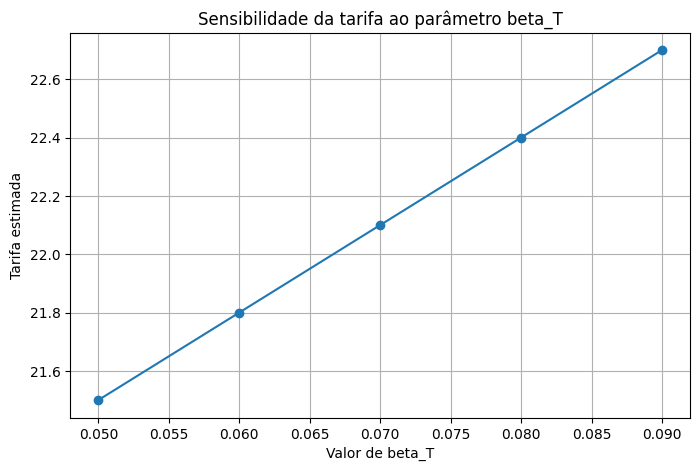

In [ ]:

plt.figure()
plt.plot(
    df_sensibilidade_beta_T["valor_parametro"],
    df_sensibilidade_beta_T["tarifa"],
    marker="o"
)
plt.xlabel("Valor de beta_T")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa ao parâmetro beta_T")
plt.show()


## 6.3 Sensibilidade ao parâmetro \(\beta_2\), associado à área

In [ ]:

# ============================================================
# 6.3 Sensibilidade ao beta_A
# ============================================================

valores_beta_A = np.arange(0.01, 0.1, 0.01)

df_sensibilidade_beta_A = sensibilidade_parametro(
    nome_parametro="beta_A",
    valores_parametro=valores_beta_A,
    operacao_base=operacao_base,
    parametros_base=parametros_base
)

df_sensibilidade_beta_A.head()


,parametro,valor_parametro,tarifa
0,beta_A,0.01,18.0
1,beta_A,0.02,20.0
2,beta_A,0.03,22.0
3,beta_A,0.04,24.0
4,beta_A,0.05,26.0


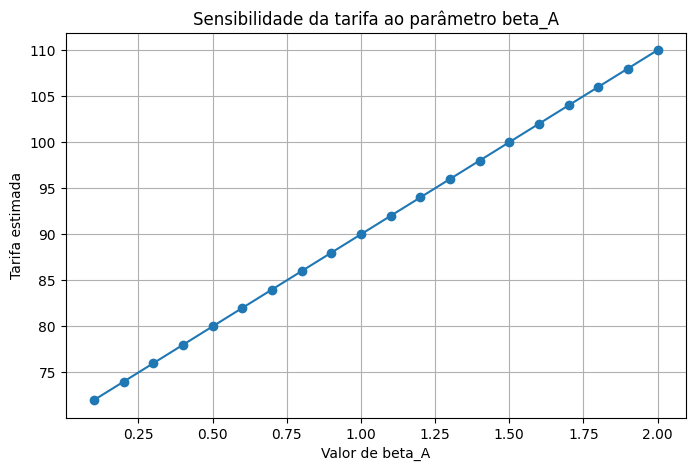

In [ ]:

plt.figure()
plt.plot(
    df_sensibilidade_beta_A["valor_parametro"],
    df_sensibilidade_beta_A["tarifa"],
    marker="o"
)
plt.xlabel("Valor de beta_A")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa ao parâmetro beta_A")
plt.show()



## 6.4 Sensibilidade ao parâmetro \(\beta_3\), associado ao horário de pico

Para que o efeito de \(\beta_3\) apareça, a operação de referência deve estar em horário de pico, isto é, com \(H = 1\).


In [ ]:

# ============================================================
# 6.4 Sensibilidade ao beta_H
# ============================================================

operacao_pico = operacao_base.copy()
operacao_pico["H"] = 1

valores_beta_H = np.arange(0, 35, 5)

df_sensibilidade_beta_H = sensibilidade_parametro(
    nome_parametro="beta_H",
    valores_parametro=valores_beta_H,
    operacao_base=operacao_pico,
    parametros_base=parametros_base
)

df_sensibilidade_beta_H


,parametro,valor_parametro,tarifa
0,beta_H,0,26.0
1,beta_H,5,31.0
2,beta_H,10,36.0
3,beta_H,15,41.0
4,beta_H,20,46.0
5,beta_H,25,51.0
6,beta_H,30,56.0


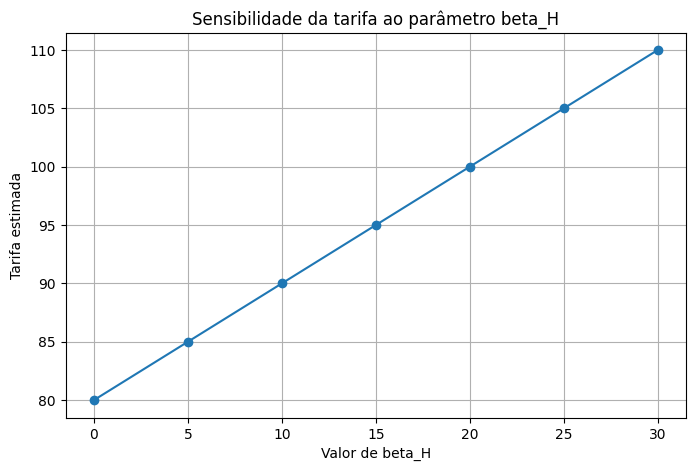

In [ ]:

plt.figure()
plt.plot(
    df_sensibilidade_beta_H["valor_parametro"],
    df_sensibilidade_beta_H["tarifa"],
    marker="o"
)
plt.xlabel("Valor de beta_H")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa ao parâmetro beta_H")
plt.show()



# 7. Sensibilidade à margem de remuneração

A margem de remuneração é aplicada multiplicando os parâmetros por \((1+m)\).


In [ ]:

# ============================================================
# 7. Função para aplicar margem de remuneração
# ============================================================

def aplicar_margem(parametros_base, margem):
    """
    Aplica uma margem de remuneração aos parâmetros tarifários.

    Exemplo:
        margem = 0.10 representa 10%.
    """

    parametros_margem = {
        "alpha": parametros_base["alpha"] * (1 + margem),
        "beta_T": parametros_base["beta_T"] * (1 + margem),
        "beta_A": parametros_base["beta_A"] * (1 + margem),
        "beta_H": parametros_base["beta_H"] * (1 + margem),
        "beta_categoria": {
            categoria: valor * (1 + margem)
            for categoria, valor in parametros_base["beta_categoria"].items()
        }
    }

    return parametros_margem


In [ ]:

# ============================================================
# 7.1 Simulação de diferentes margens de remuneração
# ============================================================

margens = np.arange(0, 0.6, 0.1)

resultados_margem = []

for m in margens:
    parametros_m = aplicar_margem(parametros_base, m)

    tarifa = calcular_tarifa(
        T=operacao_base["T"],
        A=operacao_base["A"],
        H=operacao_base["H"],
        categoria=operacao_base["categoria"],
        parametros=parametros_m
    )

    resultados_margem.append({
        "margem": m,
        "margem_percentual": m * 100,
        "tarifa": tarifa
    })

df_sensibilidade_margem = pd.DataFrame(resultados_margem)

df_sensibilidade_margem


,margem,margem_percentual,tarifa
0,0.0,0.0,26.0
1,0.1,10.0,28.6
2,0.2,20.0,31.2
3,0.3,30.0,33.8
4,0.4,40.0,36.4
5,0.5,50.0,39.0


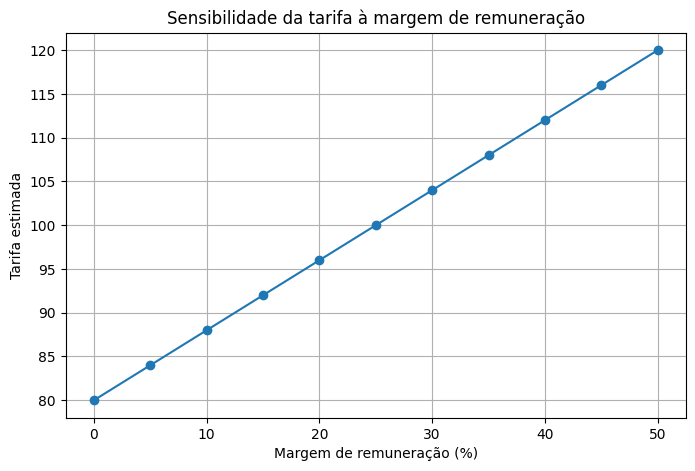

In [ ]:

plt.figure()
plt.plot(
    df_sensibilidade_margem["margem_percentual"],
    df_sensibilidade_margem["tarifa"],
    marker="o"
)
plt.xlabel("Margem de remuneração (%)")
plt.ylabel("Tarifa estimada")
plt.title("Sensibilidade da tarifa à margem de remuneração")
plt.show()



# 8. Análise multivariada de cenários

Nesta etapa, são comparadas diferentes combinações de tempo, área, horário de pico e categoria procedimental.


In [ ]:

# ============================================================
# 8. Construção de cenários operacionais
# ============================================================

cenarios = pd.DataFrame({
    "cenario": [
        "Operação simples",
        "Operação média",
        "Operação em pico",
        "Operação complexa",
        "Operação complexa em pico"
    ],
    "T": [30, 60, 90, 120, 120],
    "A": [100, 300, 300, 500, 500],
    "H": [0, 0, 1, 0, 1],
    "categoria": [
        "V0_Automatica",
        "V2_Media_complexidade",
        "V2_Media_complexidade",
        "V4_NOTAM",
        "V5_Termo_coordenacao"
    ]
})

cenarios["tarifa"] = cenarios.apply(
    lambda linha: calcular_tarifa(
        T=linha["T"],
        A=linha["A"],
        H=linha["H"],
        categoria=linha["categoria"],
        parametros=parametros_base
    ),
    axis=1
)

cenarios


,cenario,T,A,H,categoria,tarifa
0,Operação simples,30,100,0,V0_Automatica,21.0
1,Operação média,60,300,0,V2_Media_complexidade,47.0
2,Operação em pico,90,300,1,V2_Media_complexidade,68.0
3,Operação complexa,120,500,0,V4_NOTAM,89.0
4,Operação complexa em pico,120,500,1,V5_Termo_coordenacao,114.0


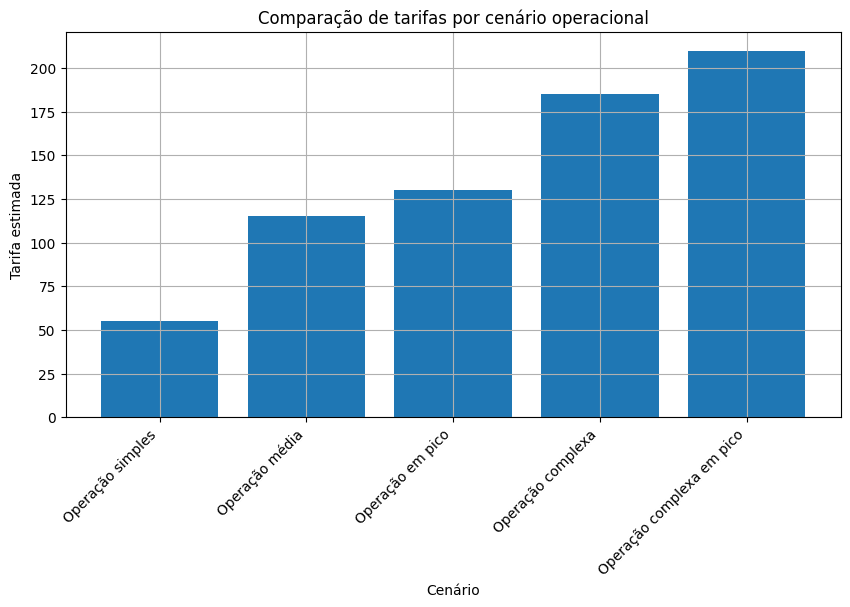

In [ ]:

plt.figure(figsize=(10, 5))
plt.bar(cenarios["cenario"], cenarios["tarifa"])
plt.xlabel("Cenário")
plt.ylabel("Tarifa estimada")
plt.title("Comparação de tarifas por cenário operacional")
plt.xticks(rotation=45, ha="right")
plt.show()



# 9. Simulação de Monte Carlo

A simulação de Monte Carlo permite observar a distribuição das tarifas quando as variáveis operacionais assumem valores aleatórios dentro de faixas plausíveis.


In [ ]:

# ============================================================
# 9. Simulação de Monte Carlo
# ============================================================

np.random.seed(123)

n_simulacoes = 10000

categorias = list(parametros_base["beta_categoria"].keys())

simulacoes = pd.DataFrame({
    "T": np.random.uniform(5, 120, n_simulacoes),
    "A": np.random.uniform(5, 100, n_simulacoes),
    "H": np.random.binomial(1, 0.25, n_simulacoes),
    "categoria": np.random.choice(categorias, n_simulacoes)
})

simulacoes["tarifa"] = simulacoes.apply(
    lambda linha: calcular_tarifa(
        T=linha["T"],
        A=linha["A"],
        H=linha["H"],
        categoria=linha["categoria"],
        parametros=parametros_base
    ),
    axis=1
)

simulacoes.head()


,T,A,H,categoria,tarifa
0,85.093956,67.998527,0,V4_NOTAM,244.187176
1,37.906024,84.779708,0,V2_Media_complexidade,138.201901
2,31.087917,83.247167,0,V5_Termo_coordenacao,153.799418
3,68.401198,39.923127,0,V0_Automatica,166.763960
4,87.738932,21.681147,0,V4_NOTAM,226.318437


In [ ]:

# Estatísticas descritivas das tarifas simuladas

simulacoes["tarifa"].describe()


,tarifa
count,10000.000000
mean,181.956760
std,69.326249
min,26.788807
25%,123.589382
50%,182.998073
75%,239.398389
max,352.389279


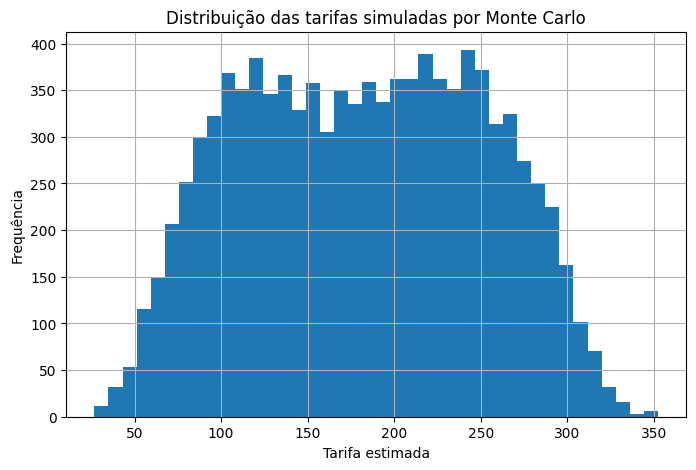

In [ ]:

plt.figure()
plt.hist(simulacoes["tarifa"], bins=40)
plt.xlabel("Tarifa estimada")
plt.ylabel("Frequência")
plt.title("Distribuição das tarifas simuladas por Monte Carlo")
plt.show()



# 10. Identificação dos fatores mais influentes

Uma forma simples de avaliar influência é calcular a correlação entre as variáveis numéricas e a tarifa.


In [ ]:

# ============================================================
# 10. Correlação entre variáveis numéricas e tarifa
# ============================================================

correlacoes = simulacoes[["T", "A", "H", "tarifa"]].corr()

correlacoes


,T,A,H,tarifa
T,1.000000,0.008152,-0.011369,0.954652
A,0.008152,1.000000,-0.000587,0.204917
H,-0.011369,-0.000587,1.000000,0.082653
tarifa,0.954652,0.204917,0.082653,1.000000


In [ ]:

correlacao_tarifa = correlacoes["tarifa"].sort_values(ascending=False)

correlacao_tarifa


,tarifa
tarifa,1.000000
T,0.954652
A,0.204917
H,0.082653



# 11. Elasticidades aproximadas

A elasticidade aproximada mede a variação percentual da tarifa em resposta a uma variação percentual em determinada variável.


In [ ]:

# ============================================================
# 11. Elasticidade aproximada
# ============================================================

def elasticidade_aproximada(variavel, aumento_percentual, operacao_base, parametros_base):
    """
    Calcula a elasticidade aproximada da tarifa em relação a uma variável.

    Parâmetros
    ----------
    variavel : str
        Variável a ser alterada. Exemplo: 'T' ou 'A'.
    aumento_percentual : float
        Aumento percentual aplicado à variável. Exemplo: 0.10 = 10%.
    """

    operacao_alterada = operacao_base.copy()

    tarifa_inicial = calcular_tarifa(
        T=operacao_base["T"],
        A=operacao_base["A"],
        H=operacao_base["H"],
        categoria=operacao_base["categoria"],
        parametros=parametros_base
    )

    operacao_alterada[variavel] = operacao_base[variavel] * (1 + aumento_percentual)

    tarifa_final = calcular_tarifa(
        T=operacao_alterada["T"],
        A=operacao_alterada["A"],
        H=operacao_alterada["H"],
        categoria=operacao_alterada["categoria"],
        parametros=parametros_base
    )

    variacao_percentual_tarifa = (tarifa_final - tarifa_inicial) / tarifa_inicial

    elasticidade = variacao_percentual_tarifa / aumento_percentual

    return {
        "variavel": variavel,
        "aumento_percentual_variavel": aumento_percentual * 100,
        "tarifa_inicial": tarifa_inicial,
        "tarifa_final": tarifa_final,
        "variacao_percentual_tarifa": variacao_percentual_tarifa * 100,
        "elasticidade_aproximada": elasticidade
    }


In [ ]:

elasticidade_T = elasticidade_aproximada(
    variavel="T",
    aumento_percentual=0.10,
    operacao_base=operacao_base,
    parametros_base=parametros_base
)

elasticidade_A = elasticidade_aproximada(
    variavel="A",
    aumento_percentual=0.10,
    operacao_base=operacao_base,
    parametros_base=parametros_base
)

df_elasticidades = pd.DataFrame([elasticidade_T, elasticidade_A])

df_elasticidades


,variavel,aumento_percentual_variavel,tarifa_inicial,tarifa_final,variacao_percentual_tarifa,elasticidade_aproximada
0,T,10.0,80.0,86.0,7.50,0.750
1,A,10.0,80.0,81.0,1.25,0.125


# 12. Tabela-resumo da análise de sensibilidade

In [ ]:

# ============================================================
# 12. Tabela-resumo das principais análises
# ============================================================

resumo_sensibilidade = pd.DataFrame({
    "Dimensão analisada": [
        "Tempo de reserva",
        "Área reservada",
        "Horário de pico",
        "Categoria procedimental",
        "Parâmetro beta_T",
        "Parâmetro beta_A",
        "Parâmetro beta_H",
        "Margem de remuneração",
        "Monte Carlo"
    ],
    "Variável ou parâmetro": [
        "T",
        "A",
        "H",
        "V_j",
        "beta_T",
        "beta_A",
        "beta_H",
        "m",
        "T, A, H, V_j"
    ],
    "Tipo de análise": [
        "Univariada",
        "Univariada",
        "Univariada",
        "Univariada",
        "Paramétrica",
        "Paramétrica",
        "Paramétrica",
        "Paramétrica",
        "Multivariada probabilística"
    ],
    "Objetivo": [
        "Avaliar o efeito do tempo sobre a tarifa",
        "Avaliar o efeito da área reservada sobre a tarifa",
        "Avaliar o adicional tarifário em períodos críticos",
        "Comparar tarifas entre níveis de complexidade operacional",
        "Avaliar a sensibilidade ao coeficiente associado ao tempo",
        "Avaliar a sensibilidade ao coeficiente associado à área",
        "Avaliar a sensibilidade ao coeficiente associado ao horário de pico",
        "Avaliar o impacto da remuneração sobre a tarifa final",
        "Avaliar a distribuição geral das tarifas sob incerteza"
    ]
})

resumo_sensibilidade


,Dimensão analisada,Variável ou parâmetro,Tipo de análise,Objetivo
0,Tempo de reserva,T,Univariada,Avaliar o efeito do tempo sobre a tarifa
1,Área reservada,A,Univariada,Avaliar o efeito da área reservada sobre a tarifa
2,Horário de pico,H,Univariada,Avaliar o adicional tarifário em períodos crít...
3,Categoria procedimental,V_j,Univariada,Comparar tarifas entre níveis de complexidade ...
4,Parâmetro beta_T,beta_T,Paramétrica,Avaliar a sensibilidade ao coeficiente associa...
5,Parâmetro beta_A,beta_A,Paramétrica,Avaliar a sensibilidade ao coeficiente associa...
6,Parâmetro beta_H,beta_H,Paramétrica,Avaliar a sensibilidade ao coeficiente associa...
7,Margem de remuneração,m,Paramétrica,Avaliar o impacto da remuneração sobre a tarif...
8,Monte Carlo,"T, A, H, V_j",Multivariada probabilística,Avaliar a distribuição geral das tarifas sob i...



# 13. Exportação dos resultados

O código abaixo gera um arquivo Excel com todas as tabelas da análise. No Colab, o arquivo será salvo no ambiente da sessão e poderá ser baixado pela aba lateral de arquivos.


In [ ]:

# ============================================================
# 13. Exportação dos resultados para Excel
# ============================================================

nome_arquivo = "analise_sensibilidade_tarifaria.xlsx"

with pd.ExcelWriter(nome_arquivo) as writer:
    df_sensibilidade_T.to_excel(writer, sheet_name="Sensibilidade_T", index=False)
    df_sensibilidade_A.to_excel(writer, sheet_name="Sensibilidade_A", index=False)
    df_sensibilidade_H.to_excel(writer, sheet_name="Sensibilidade_H", index=False)
    df_sensibilidade_categoria.to_excel(writer, sheet_name="Sens_Categoria", index=False)
    df_sensibilidade_beta_T.to_excel(writer, sheet_name="Sens_beta_T", index=False)
    df_sensibilidade_beta_A.to_excel(writer, sheet_name="Sens_beta_A", index=False)
    df_sensibilidade_beta_H.to_excel(writer, sheet_name="Sens_beta_H", index=False)
    df_sensibilidade_margem.to_excel(writer, sheet_name="Sens_Margem", index=False)
    cenarios.to_excel(writer, sheet_name="Cenarios", index=False)
    simulacoes.to_excel(writer, sheet_name="Monte_Carlo", index=False)
    df_elasticidades.to_excel(writer, sheet_name="Elasticidades", index=False)
    resumo_sensibilidade.to_excel(writer, sheet_name="Resumo", index=False)

print(f"Arquivo '{nome_arquivo}' exportado com sucesso.")


In [ ]:

# ============================================================
# 14. Download automático no Google Colab
# ============================================================

try:
    from google.colab import files
    files.download(nome_arquivo)
except ImportError:
    print("Este comando funciona automaticamente apenas no Google Colab.")
    print(f"Arquivo salvo localmente como: {nome_arquivo}")


In [ ]:
# ============================================================
# TABELA 1 — Consolidação das análises de sensibilidade
# ============================================================

# Sensibilidade ao tempo T
tab_T = df_sensibilidade_T.copy()
tab_T["analise"] = "Sensibilidade à variável operacional"
tab_T["dimensao"] = "Tempo de reserva"
tab_T["variavel_parametro"] = "T"
tab_T = tab_T.rename(columns={"T": "valor_analisado"})
tab_T["descricao"] = "Tempo de reserva"
tab_T = tab_T[["analise", "dimensao", "variavel_parametro",
               "descricao", "valor_analisado", "tarifa"]]


# Sensibilidade à área A
tab_A = df_sensibilidade_A.copy()
tab_A["analise"] = "Sensibilidade à variável operacional"
tab_A["dimensao"] = "Área reservada"
tab_A["variavel_parametro"] = "A"
tab_A = tab_A.rename(columns={"A": "valor_analisado"})
tab_A["descricao"] = "Área reservada"
tab_A = tab_A[["analise", "dimensao", "variavel_parametro",
               "descricao", "valor_analisado", "tarifa"]]


# Sensibilidade ao horário de pico H
tab_H = df_sensibilidade_H.copy()
tab_H["analise"] = "Sensibilidade à variável operacional"
tab_H["dimensao"] = "Horário de pico"
tab_H["variavel_parametro"] = "H"
tab_H = tab_H.rename(columns={"H": "valor_analisado"})
tab_H = tab_H[["analise", "dimensao", "variavel_parametro",
               "descricao", "valor_analisado", "tarifa"]]


# Sensibilidade à categoria procedimental
tab_categoria = df_sensibilidade_categoria.copy()
tab_categoria["analise"] = "Sensibilidade à variável operacional"
tab_categoria["dimensao"] = "Categoria procedimental"
tab_categoria["variavel_parametro"] = "V_j"
tab_categoria = tab_categoria.rename(columns={"categoria": "descricao"})
tab_categoria["valor_analisado"] = tab_categoria["descricao"]
tab_categoria = tab_categoria[["analise", "dimensao", "variavel_parametro",
                               "descricao", "valor_analisado", "tarifa"]]


# Sensibilidade aos parâmetros beta_T, beta_A e beta_H
tab_parametros = pd.concat(
    [
        df_sensibilidade_beta_T,
        df_sensibilidade_beta_A,
        df_sensibilidade_beta_H
    ],
    ignore_index=True
)

tab_parametros["analise"] = "Sensibilidade paramétrica"
tab_parametros["dimensao"] = tab_parametros["parametro"].map({
    "beta_T": "Coeficiente do tempo de reserva",
    "beta_A": "Coeficiente da área reservada",
    "beta_H": "Coeficiente do horário de pico"
})
tab_parametros["variavel_parametro"] = tab_parametros["parametro"]
tab_parametros["descricao"] = tab_parametros["parametro"]
tab_parametros = tab_parametros.rename(columns={"valor_parametro": "valor_analisado"})
tab_parametros = tab_parametros[["analise", "dimensao", "variavel_parametro",
                                 "descricao", "valor_analisado", "tarifa"]]


# Sensibilidade à margem de remuneração
tab_margem = df_sensibilidade_margem.copy()
tab_margem["analise"] = "Sensibilidade paramétrica"
tab_margem["dimensao"] = "Margem de remuneração"
tab_margem["variavel_parametro"] = "m"
tab_margem["descricao"] = "Margem percentual"
tab_margem = tab_margem.rename(columns={"margem_percentual": "valor_analisado"})
tab_margem = tab_margem[["analise", "dimensao", "variavel_parametro",
                         "descricao", "valor_analisado", "tarifa"]]


# Tabela consolidada final
tabela_sensibilidade_consolidada = pd.concat(
    [
        tab_T,
        tab_A,
        tab_H,
        tab_categoria,
        tab_parametros,
        tab_margem
    ],
    ignore_index=True
)

# Arredondamento para melhor visualização
tabela_sensibilidade_consolidada["tarifa"] = tabela_sensibilidade_consolidada["tarifa"].round(2)

tabela_sensibilidade_consolidada

,analise,dimensao,variavel_parametro,descricao,valor_analisado,tarifa
0,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,30,26.0
1,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,40,28.0
2,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,50,30.0
3,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,60,32.0
4,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,70,34.0
5,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,80,36.0
6,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,90,38.0
7,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,100,40.0
8,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,110,42.0
9,Sensibilidade à variável operacional,Tempo de reserva,T,Tempo de reserva,120,44.0


In [ ]:
# ============================================================
# TABELA 1 — Sensibilidade às variáveis operacionais
# ============================================================

# Tarifa da operação base
tarifa_base = calcular_tarifa(
    T=operacao_base["T"],
    A=operacao_base["A"],
    H=operacao_base["H"],
    categoria=operacao_base["categoria"],
    parametros=parametros_base
)

# ------------------------------------------------------------
# Sensibilidade ao tempo de reserva T
# ------------------------------------------------------------

tab_T = df_sensibilidade_T.copy()

tab_T["dimensao_analisada"] = "Tempo de reserva"
tab_T["variavel"] = "T"
tab_T["descricao"] = "Tempo de reserva"
tab_T = tab_T.rename(columns={"T": "valor_analisado"})

tab_T = tab_T[[
    "dimensao_analisada",
    "variavel",
    "descricao",
    "valor_analisado",
    "tarifa"
]]


# ------------------------------------------------------------
# Sensibilidade à área reservada A
# ------------------------------------------------------------

tab_A = df_sensibilidade_A.copy()

tab_A["dimensao_analisada"] = "Área reservada"
tab_A["variavel"] = "A"
tab_A["descricao"] = "Área reservada"
tab_A = tab_A.rename(columns={"A": "valor_analisado"})

tab_A = tab_A[[
    "dimensao_analisada",
    "variavel",
    "descricao",
    "valor_analisado",
    "tarifa"
]]


# ------------------------------------------------------------
# Sensibilidade ao horário de pico H
# ------------------------------------------------------------

tab_H = df_sensibilidade_H.copy()

tab_H["dimensao_analisada"] = "Horário de pico"
tab_H["variavel"] = "H"
tab_H = tab_H.rename(columns={"H": "valor_analisado"})

tab_H = tab_H[[
    "dimensao_analisada",
    "variavel",
    "descricao",
    "valor_analisado",
    "tarifa"
]]


# ------------------------------------------------------------
# Sensibilidade às categorias procedimentais V_j
# ------------------------------------------------------------

tab_categoria = df_sensibilidade_categoria.copy()

tab_categoria["dimensao_analisada"] = "Categoria procedimental"
tab_categoria["variavel"] = "V_j"
tab_categoria = tab_categoria.rename(columns={"categoria": "descricao"})
tab_categoria["valor_analisado"] = tab_categoria["descricao"]

tab_categoria = tab_categoria[[
    "dimensao_analisada",
    "variavel",
    "descricao",
    "valor_analisado",
    "tarifa"
]]


# ------------------------------------------------------------
# Consolidação final
# ------------------------------------------------------------

tabela_variaveis_operacionais = pd.concat(
    [
        tab_T,
        tab_A,
        tab_H,
        tab_categoria
    ],
    ignore_index=True
)

# Cálculo da variação em relação à tarifa base
tabela_variaveis_operacionais["tarifa_base"] = tarifa_base

tabela_variaveis_operacionais["variacao_absoluta"] = (
    tabela_variaveis_operacionais["tarifa"]
    - tabela_variaveis_operacionais["tarifa_base"]
)

tabela_variaveis_operacionais["variacao_percentual"] = (
    tabela_variaveis_operacionais["variacao_absoluta"]
    / tabela_variaveis_operacionais["tarifa_base"]
) * 100

# Arredondamento
tabela_variaveis_operacionais["tarifa"] = tabela_variaveis_operacionais["tarifa"].round(2)
tabela_variaveis_operacionais["tarifa_base"] = tabela_variaveis_operacionais["tarifa_base"].round(2)
tabela_variaveis_operacionais["variacao_absoluta"] = tabela_variaveis_operacionais["variacao_absoluta"].round(2)
tabela_variaveis_operacionais["variacao_percentual"] = tabela_variaveis_operacionais["variacao_percentual"].round(2)

tabela_variaveis_operacionais

,dimensao_analisada,variavel,descricao,valor_analisado,tarifa,tarifa_base,variacao_absoluta,variacao_percentual
0,Tempo de reserva,T,Tempo de reserva,30,26.0,26.0,0.0,0.00
1,Tempo de reserva,T,Tempo de reserva,40,28.0,26.0,2.0,7.69
2,Tempo de reserva,T,Tempo de reserva,50,30.0,26.0,4.0,15.38
3,Tempo de reserva,T,Tempo de reserva,60,32.0,26.0,6.0,23.08
4,Tempo de reserva,T,Tempo de reserva,70,34.0,26.0,8.0,30.77
5,Tempo de reserva,T,Tempo de reserva,80,36.0,26.0,10.0,38.46
6,Tempo de reserva,T,Tempo de reserva,90,38.0,26.0,12.0,46.15
7,Tempo de reserva,T,Tempo de reserva,100,40.0,26.0,14.0,53.85
8,Tempo de reserva,T,Tempo de reserva,110,42.0,26.0,16.0,61.54
9,Tempo de reserva,T,Tempo de reserva,120,44.0,26.0,18.0,69.23
